In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df_students = pd.read_csv('../data/processed/students_features.csv')

print(f"✅ Données chargées : {len(df_students)} étudiants prêts pour l'IA.")
display(df_students.head())

✅ Données chargées : 147 étudiants prêts pour l'IA.


,id_etudiant,moyenne_generale,nb_absences,id,nom,prenom,nom_complet,score_risque,segmentation
0,1,13.500000,4,1,Rodriguez,Léna,Rodriguez Léna,8.0,Excellent
1,3,12.000000,2,3,Paul,Jacques,Paul Jacques,4.0,Excellent
2,4,10.000000,2,4,Carpentier,Joël,Carpentier Joël,4.0,Excellent
3,5,10.666667,1,5,Leclercq,Anne,Leclercq Anne,2.0,Excellent
4,6,13.000000,5,6,Roche,Albéric,Roche Albéric,10.0,Excellent


In [4]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
# On transforme les données
features_scaled = scaler.fit_transform(df_students[['moyenne_generale', 'nb_absences']])

print("✅ Données mises à l'échelle pour l'IA.")

✅ Données mises à l'échelle pour l'IA.


In [5]:
from sklearn.cluster import KMeans

# On crée le modèle : on veut 5 groupes (comme tes 5 catégories)
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)

# On lance l'entraînement (fit) et on prédit le groupe de chaque étudiant (predict)
df_students['Groupe_IA'] = kmeans.fit_predict(features_scaled)

print("🤖 L'IA a terminé de segmenter les étudiants automatiquement !")

🤖 L'IA a terminé de segmenter les étudiants automatiquement !


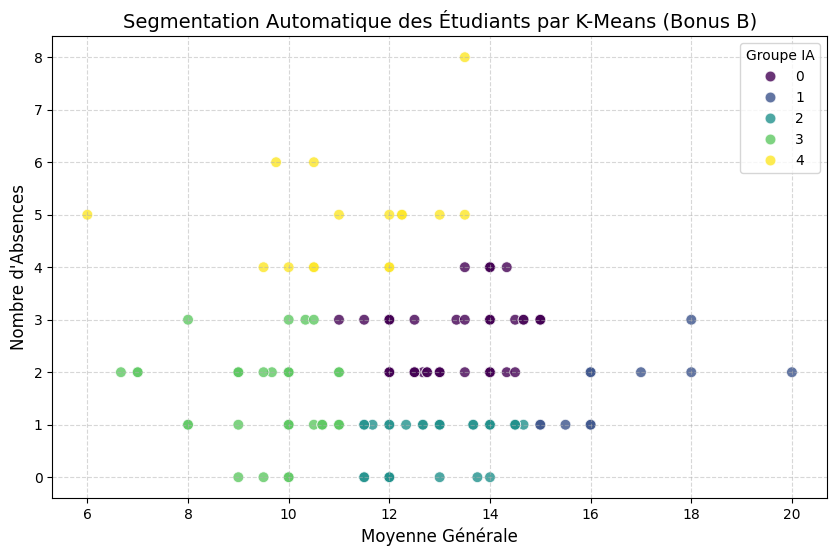

In [6]:
plt.figure(figsize=(10, 6))

# On dessine chaque étudiant avec une couleur selon son "Groupe_IA"
scatter = sns.scatterplot(
    data=df_students, 
    x='moyenne_generale', 
    y='nb_absences', 
    hue='Groupe_IA', 
    palette='viridis', 
    s=60, # taille des points
    alpha=0.8
)

plt.title("Segmentation Automatique des Étudiants par K-Means (Bonus B)", fontsize=14)
plt.xlabel("Moyenne Générale", fontsize=12)
plt.ylabel("Nombre d'Absences", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Groupe IA')
plt.show()